In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform)
val_dataset   = ChestMNIST(split='val',   download=True, size=64, transform=transform)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("Data chargée ")

Data chargée 


In [4]:
class CNNScratch(nn.Module):
    def __init__(self, num_classes=14):
        super(CNNScratch, self).__init__()
        
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64 -> 32

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32 -> 16

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16 -> 8
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
            # Pas de sigmoid ici, on l'applique dans la loss
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNNScratch(num_classes=14)
print(model)

CNNScratch(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=Tru

In [5]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

model = model.to(device)

# Loss multi-label + optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Seed pour reproductibilité
torch.manual_seed(42)
np.random.seed(42)

Device : cpu


In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # ── Validation ──
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.float().to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=3)

Epoch [1/3] | Train Loss: 0.1686 | Val Loss: 0.1629
Epoch [2/3] | Train Loss: 0.1659 | Val Loss: 0.1638
Epoch [3/3] | Train Loss: 0.1639 | Val Loss: 0.1637


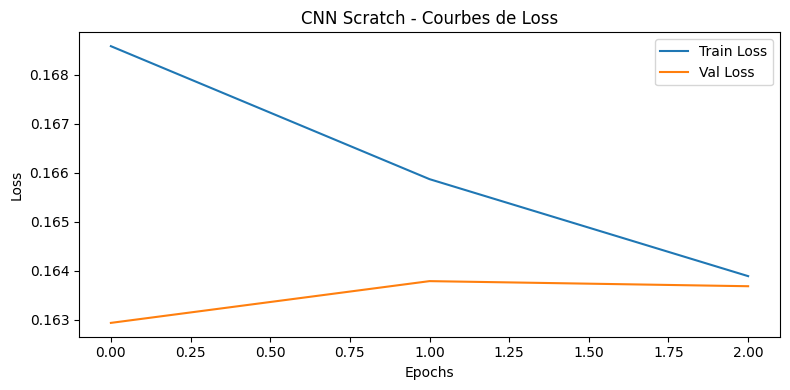

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Scratch - Courbes de Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import roc_auc_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# AUC par classe
label_names = list(test_dataset.info['label'].values())
aucs = []
for i, name in enumerate(label_names):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    aucs.append(auc)
    print(f"{name:20s} : AUC = {auc:.4f}")

print(f"\nAUC moyen : {np.mean(aucs):.4f}")

atelectasis          : AUC = 0.7478
cardiomegaly         : AUC = 0.8298
effusion             : AUC = 0.8304
infiltration         : AUC = 0.6693
mass                 : AUC = 0.6810
nodule               : AUC = 0.6162
pneumonia            : AUC = 0.6760
pneumothorax         : AUC = 0.7656
consolidation        : AUC = 0.7764
edema                : AUC = 0.8563
emphysema            : AUC = 0.7390
fibrosis             : AUC = 0.7327
pleural              : AUC = 0.6978
hernia               : AUC = 0.7635

AUC moyen : 0.7416


In [11]:
from sklearn.metrics import roc_auc_score, f1_score

# Seuil à 0.5 pour convertir les proba en 0/1
all_preds_binary = (all_preds >= 0.5).astype(int)

# F1 par classe
print("=" * 45)
print(f"{'Pathologie':<20} | {'AUC':>6} | {'F1':>6}")
print("=" * 45)
for i, name in enumerate(label_names):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    f1 = f1_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    print(f"{name:<20} | {auc:>6.4f} | {f1:>6.4f}")

print("=" * 45)
print(f"{'Moyenne':<20} | {np.mean(aucs):>6.4f} | {f1_score(all_labels, all_preds_binary, average='macro', zero_division=0):>6.4f}")

torch.save(model.state_dict(), 'cnn_scratch.pth')
print("\nModèle sauvegardé ")

Pathologie           |    AUC |     F1
atelectasis          | 0.7478 | 0.0000
cardiomegaly         | 0.8298 | 0.0000
effusion             | 0.8304 | 0.0661
infiltration         | 0.6693 | 0.0000
mass                 | 0.6810 | 0.0000
nodule               | 0.6162 | 0.0000
pneumonia            | 0.6760 | 0.0000
pneumothorax         | 0.7656 | 0.0000
consolidation        | 0.7764 | 0.0000
edema                | 0.8563 | 0.0000
emphysema            | 0.7390 | 0.0000
fibrosis             | 0.7327 | 0.0000
pleural              | 0.6978 | 0.0000
hernia               | 0.7635 | 0.0000
Moyenne              | 0.7416 | 0.0047

Modèle sauvegardé 
